# Diversity Analysis for each school
This notebook aims to concretize the analysis of relation between median earning post-grad and the diversity of each school. As such, it uses data obtained from the `university_racial` notebook and data from `glynn_provisional_analysis`.

In [1]:
#setup chunk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
from IPython.display import IFrame, Markdown, display
import statsmodels.formula.api as smf

To start, we want to load all of the relevant data needed, included the similarity scores of each university and the data on median earnings.

In [2]:
sim = pd.read_csv('../data/university_similarity.csv')
sim.columns

Index(['COUNTY', 'univ_id', 'univ_name', 'race_proportion_vector',
       'diversity_index', 'State_FIPS', 'similarity_to_national',
       'similarity_to_state', 'similarity_to_county'],
      dtype='str')

In [3]:
dat = pd.read_csv('../data/Glynn_data/combined_data.csv')
dat.columns

Index(['univ_id', 'univ_name', 'state', 'zip_code', 'percent_pell',
       'completion_rate_fry', 'ugds_white', 'ugds_black', 'ugds_hisp',
       'ugds_asian', 'ugds_aian', 'ugds_nhpi', 'ugds_2mor', 'ugds_nra',
       'ugds_unkn', 'ugds_men', 'ugds_women', 'md_earn_wne_4yr', 'year',
       'hbcu', 'pbi', 'aanapii', 'hsi', 'tribal', 'long', 'all_male',
       'all_female', 'admit_rate', 'lat', 'pct_w_ba_hometown', 'degree_type'],
      dtype='str')

In [4]:
#then narrow only to universities in upper-50 US (no PR or Guam)
dat['state'].value_counts()
non_50 = ['VI', 'AS', 'MP', 'FM', 'PW', 'MH', 'GU', 'PR']
    #virgin islands, american samoa, northern marina islands, federated state of micronesia, palao, guam, puerto rico

dat[~dat['state'].isin(non_50)].nunique() #taking out states not in the 50 states gives us 51 unique states (since the dataset includes DC)
#filtering
dat = dat[~dat['state'].isin(non_50)]

In [6]:
dat = dat[dat['degree_type']==3]

In [11]:
# Merge the two dataframes on univ_id
dat['md_earn_wne_4yr'] = pd.to_numeric(dat['md_earn_wne_4yr'], errors='coerce')
merged = dat.merge(
    sim[['univ_id', 'diversity_index', 'similarity_to_national', 
         'similarity_to_state', 'similarity_to_county']],
    on='univ_id',
    how='inner'
)[['univ_id', 'univ_name', 'md_earn_wne_4yr', 'diversity_index', 
   'similarity_to_national', 'similarity_to_state', 'similarity_to_county']]



In [12]:
merged

,univ_id,univ_name,md_earn_wne_4yr,diversity_index,similarity_to_national,similarity_to_state,similarity_to_county
0,100654,Alabama A & M University,54018.0,0.8045,0.211625,0.388022,0.369349
1,100663,University of Alabama at Birmingham,64969.0,0.3413,0.490277,0.349466,0.452353
2,100690,Amridge University,50075.0,0.5211,0.339893,0.413371,0.844064
3,100706,University of Alabama in Huntsville,81045.0,0.5208,0.427433,0.210909,0.231457
4,100724,Alabama State University,45998.0,0.8564,0.210471,0.388572,0.874359
...,...,...,...,...,...,...,...
1892,498049,Arizona College of Nursing-Southfield,38251.0,0.4627,0.395171,0.315655,0.319029
1893,498447,Arizona College of Nursing-Falls Church,38251.0,0.3781,0.500408,0.558033,0.489030
1894,498456,Arizona College of Nursing-Ontario,38251.0,0.3395,0.980461,0.793736,0.615397
1895,498562,Commonwealth University of Pennsylvania,58676.0,0.6504,0.403706,0.198049,0.117546


Now that we have the relevant merged data, we conduct an Ordinary Least Squares (OLS) regression analysis using the statsmodels library to investigate the relationship between institutional diversity and post-graduation earnings.

In [13]:
import statsmodels.api as sm

# Drop rows with any NaN in the relevant columns
reg_df = merged[['md_earn_wne_4yr', 'diversity_index', 'similarity_to_national',
                  'similarity_to_state', 'similarity_to_county']].dropna()

print(f"Regression sample size: {len(reg_df)}")

# Convert outcome to numeric just in case
reg_df['md_earn_wne_4yr'] = pd.to_numeric(reg_df['md_earn_wne_4yr'], errors='coerce')
reg_df = reg_df.dropna()

# Define X and y
X = reg_df[['diversity_index', 'similarity_to_national', 
            'similarity_to_state', 'similarity_to_county']]
y = reg_df['md_earn_wne_4yr']

# Add constant for intercept
X = sm.add_constant(X)

# Fit OLS
model = sm.OLS(y, X).fit()
print(model.summary())

Regression sample size: 1751
                            OLS Regression Results                            
Dep. Variable:        md_earn_wne_4yr   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     39.69
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           7.48e-32
Time:                        05:03:38   Log-Likelihood:                -19470.
No. Observations:                1751   AIC:                         3.895e+04
Df Residuals:                    1746   BIC:                         3.898e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------


The OLS regression analysis, based on a sample size of 1,751 observations, suggests that the selected predictors have a statistically significant but limited overall impact on median earnings, as indicated by an R^2 of 0.083. This value implies that the model explains approximately 8.3% of the variance in post-graduation income. Notably, the diversity_index is the only predictor with a statistically significant relationship (p<0.001), showing a strong negative coefficient of -27,990. This suggests that, within this specific dataset and model configuration, higher diversity scores are associated with lower median earnings when other factors are held constant. In contrast, the similarity metrics relative to national, state, and county demographics all yielded high p-values (well above the 0.05 threshold), indicating that these geographic alignment factors do not have a statistically significant effect on earnings. Finally, the Durbin-Watson score of 1.795 suggests minimal autocorrelation in the residuals, though the Omnibus and Jarque-Bera tests indicate that the residuals are not normally distributed, potentially suggesting that a non-linear model or additional control variables might better capture the underlying economic complexities.

To refine the previous analysis, the following code introduces a logarithmic transformation to the dependent variable, `md_earn_wne_4yr`, effectively shifting the model to a log-linear regression framework.

In [14]:
import numpy as np

reg_df['log_earnings'] = np.log(reg_df['md_earn_wne_4yr'])

X = sm.add_constant(reg_df[['diversity_index', 'similarity_to_national',
                              'similarity_to_state', 'similarity_to_county']])
model_log = sm.OLS(reg_df['log_earnings'], X).fit()
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:           log_earnings   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     43.17
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           1.41e-34
Time:                        05:04:49   Log-Likelihood:                -83.827
No. Observations:                1751   AIC:                             177.7
Df Residuals:                    1746   BIC:                             205.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     11


The log-linear regression results show a slight improvement in model fit, with the R^2 increasing to 0.090, indicating that the predictors now explain 9% of the variance in the natural log of earnings. In this model, the diversity_index remains highly significant (p<0.001) with a coefficient of -0.4455; in a log-linear context, this suggests that a one-unit increase in the diversity index is associated with an approximate 44.5% decrease in median earnings, holding other factors constant. Interestingly, similarity_to_national has now become statistically significant (p=0.038), with a positive coefficient of 0.1318, implying that institutions with demographics more aligned with the national average tend to see higher graduate earnings. The state and county similarity metrics remain statistically insignificant. While the Durbin-Watson statistic (1.814) still indicates no major issues with autocorrelation, the significant Jarque-Bera test and a kurtosis of 4.511 suggest that the residuals, while improved from the linear model, still deviate from a perfectly normal distribution.

Now, we want to control some of the variation using other data from the College Scorecard, including the percent of students on Pell grants, admission rate, and school designation (HBCU, HSI).

In [15]:
# Merge controls from dat into reg_df
controls = ['percent_pell', 'admit_rate', 'degree_type', 'hbcu', 'hsi', 'pbi']

reg_df2 = merged.merge(
    dat[['univ_id'] + controls], on='univ_id', how='left'
)
reg_df2['log_earnings'] = np.log(pd.to_numeric(reg_df2['md_earn_wne_4yr'], errors='coerce'))

# Convert controls to numeric
for col in ['percent_pell', 'admit_rate']:
    reg_df2[col] = pd.to_numeric(reg_df2[col], errors='coerce')

# Dummies for degree_type
reg_df2 = pd.get_dummies(reg_df2, columns=['degree_type'], drop_first=True)

reg_df2 = reg_df2.dropna(subset=['log_earnings', 'diversity_index', 
                                   'similarity_to_national', 'percent_pell'])
print(reg_df2.shape)

(1745, 13)


In [16]:
degree_cols = [c for c in reg_df2.columns if c.startswith('degree_type_')]
print(degree_cols)

# Build feature list
feature_cols = ['diversity_index', 'similarity_to_national', 'similarity_to_state',
                'similarity_to_county', 'percent_pell', 'admit_rate', 
                'hbcu', 'hsi', 'pbi'] + degree_cols

# Convert indicator variables to numeric
for col in ['hbcu', 'hsi', 'pbi']:
    reg_df2[col] = pd.to_numeric(reg_df2[col], errors='coerce')

# Drop rows with NaN in any feature
reg_df2_clean = reg_df2.dropna(subset=feature_cols + ['log_earnings'])
print(f"Final sample: {len(reg_df2_clean)}")

X = sm.add_constant(reg_df2_clean[feature_cols])
y = reg_df2_clean['log_earnings']

model_controls = sm.OLS(y, X).fit()
print(model_controls.summary())

[]
Final sample: 1464
                            OLS Regression Results                            
Dep. Variable:           log_earnings   R-squared:                       0.265
Model:                            OLS   Adj. R-squared:                  0.260
Method:                 Least Squares   F-statistic:                     58.13
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           7.83e-91
Time:                        05:06:41   Log-Likelihood:                 211.17
No. Observations:                1464   AIC:                            -402.3
Df Residuals:                    1454   BIC:                            -349.4
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const 

The addition of control variables significantly improves the model's explanatory power, with the R^2 jumping to 0.265, meaning the model now accounts for 26.5% of the variance in log earnings. While the diversity_index remains a significant negative predictor (p=0.002), its magnitude has decreased to -0.1635, suggesting that much of its previous effect was likely captured by socioeconomic factors like percent_pell (coefficient -0.8225, p<0.001), which shows that a higher proportion of low-income students strongly correlates with lower median earnings.

Geographic alignment also becomes more nuanced: both similarity_to_national (p=0.001) and similarity_to_county (p=0.027) are now significant positive predictors. Furthermore, the model reveals that admit_rate is negatively correlated with earnings (p<0.001), reinforcing the link between institutional selectivity and financial outcomes. Interestingly, being an HBCU (Historically Black College or University) has a significant positive coefficient of 0.1054 (p=0.012), indicating an approximately 10.5% increase in median earnings compared to non-minority-serving institutions when controlling for the other variables in the model. In contrast, status as an HSI or PBI does not show a statistically significant impact in this iteration.

It is important to visualize the regression findings through a series of exploratory scatter plots. We generate a three-panel figure comparing the logged median earnings against the three geographic similarity metrics: National, State, and County levels.

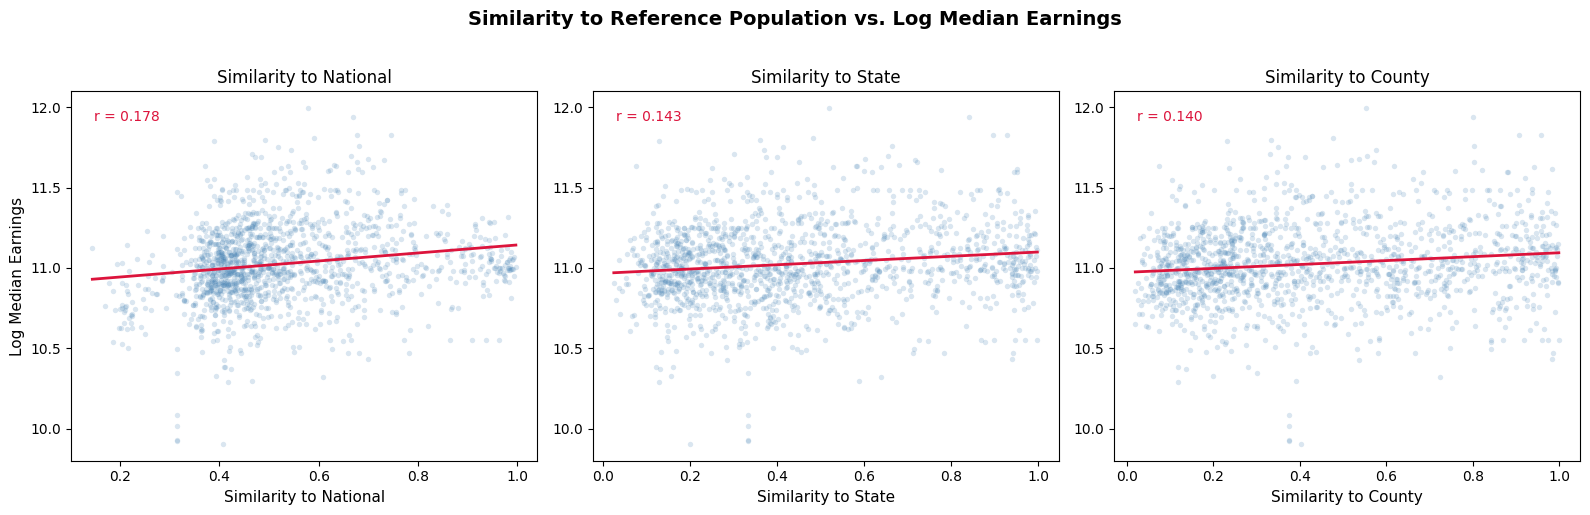

In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

sim_vars = ['similarity_to_national', 'similarity_to_state', 'similarity_to_county']
titles = ['Similarity to National', 'Similarity to State', 'Similarity to County']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Similarity to Reference Population vs. Log Median Earnings', 
             fontsize=14, fontweight='bold', y=1.02)

for ax, var, title in zip(axes, sim_vars, titles):
    x = reg_df2_clean[var]
    y = reg_df2_clean['log_earnings']
    
    # Scatter
    ax.scatter(x, y, alpha=0.2, s=15, color='steelblue', linewidths=0)
    
    # OLS trend line
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2)
    
    ax.set_xlabel(title, fontsize=11)
    ax.set_ylabel('Log Median Earnings' if var == sim_vars[0] else '', fontsize=11)
    ax.set_title(title, fontsize=12)
    
    # Annotate correlation
    r = np.corrcoef(x, y)[0, 1]
    ax.annotate(f'r = {r:.3f}', xy=(0.05, 0.92), xycoords='axes fraction',
                fontsize=10, color='crimson')

plt.tight_layout()
plt.savefig('similarity_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

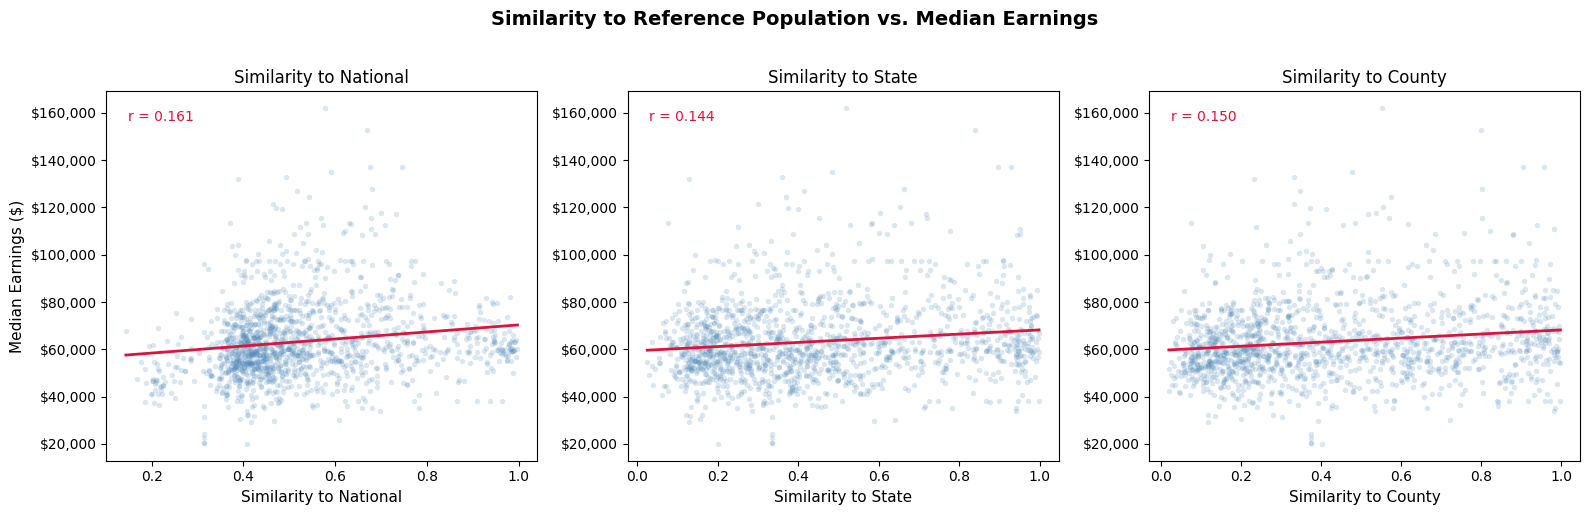

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Similarity to Reference Population vs. Median Earnings', 
             fontsize=14, fontweight='bold', y=1.02)

sim_vars = ['similarity_to_national', 'similarity_to_state', 'similarity_to_county']
titles = ['Similarity to National', 'Similarity to State', 'Similarity to County']

for ax, var, title in zip(axes, sim_vars, titles):
    x = reg_df2_clean[var]
    y = pd.to_numeric(reg_df2_clean['md_earn_wne_4yr'], errors='coerce')
    
    # Remove NaNs for this pair
    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]
    
    ax.scatter(x, y, alpha=0.2, s=15, color='steelblue', linewidths=0)
    
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2)
    
    ax.set_xlabel(title, fontsize=11)
    ax.set_ylabel('Median Earnings ($)' if var == sim_vars[0] else '', fontsize=11)
    ax.set_title(title, fontsize=12)
    
    # Format y axis as dollars
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    
    r = np.corrcoef(x, y)[0, 1]
    ax.annotate(f'r = {r:.3f}', xy=(0.05, 0.92), xycoords='axes fraction',
                fontsize=10, color='crimson')

plt.tight_layout()
plt.savefig('similarity_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

Now we use a forest plot to provide a  visual summary of the multivariate regression results. By plotting each predictor's coefficient alongside its 95% confidence interval, the visualization allows for an assessment of both the magnitude and the reliability of each effect. To ensure technical rigor, the model incorporates HC3 robust standard errors, which adjust the results for heteroskedasticity, making the findings more resilient against non-constant variance in the data.

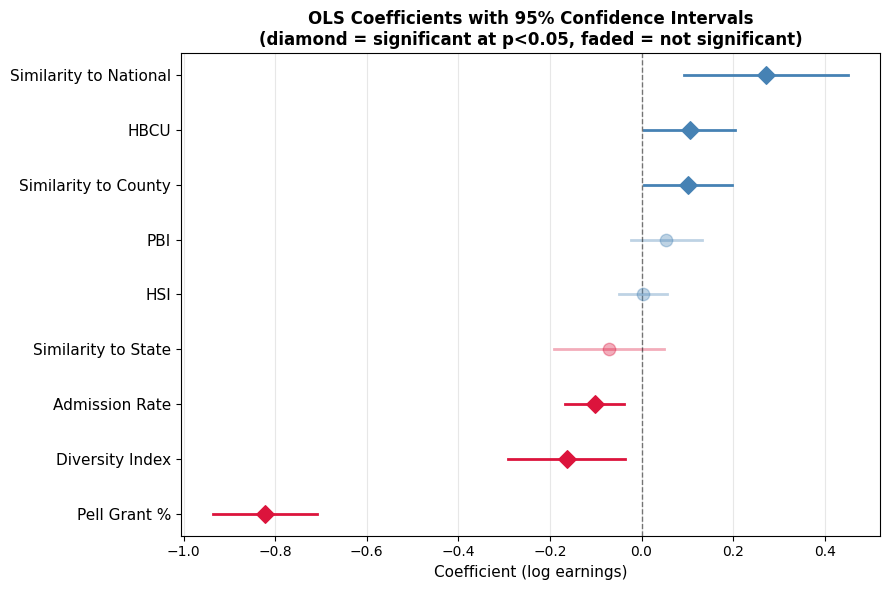

In [20]:
X = sm.add_constant(reg_df2_clean[feature_cols])
y = reg_df2_clean['log_earnings']

model_robust = sm.OLS(y, X).fit(cov_type='HC3')
# Extract coefficients and confidence intervals from the robust model
coef = model_robust.params
ci = model_robust.conf_int()
pvals = model_robust.pvalues

# Exclude the constant
coef = coef.drop('const')
ci = ci.drop('const')
pvals = pvals.drop('const')

# Nicer labels
labels = {
    'diversity_index': 'Diversity Index',
    'similarity_to_national': 'Similarity to National',
    'similarity_to_state': 'Similarity to State',
    'similarity_to_county': 'Similarity to County',
    'percent_pell': 'Pell Grant %',
    'admit_rate': 'Admission Rate',
    'hbcu': 'HBCU',
    'hsi': 'HSI',
    'pbi': 'PBI'
}

# Sort by coefficient value
order = coef.sort_values().index
coef = coef[order]
ci = ci.loc[order]
pvals = pvals[order]

fig, ax = plt.subplots(figsize=(9, 6))

for i, var in enumerate(order):
    significant = pvals[var] < 0.05
    color = 'steelblue' if coef[var] > 0 else 'crimson'
    alpha = 1.0 if significant else 0.35

    # CI line
    ax.plot([ci.loc[var, 0], ci.loc[var, 1]], [i, i],
            color=color, alpha=alpha, linewidth=2)
    # Point
    ax.scatter(coef[var], i, color=color, alpha=alpha, 
               s=80, zorder=5, marker='D' if significant else 'o')

# Zero line
ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)

ax.set_yticks(range(len(order)))
ax.set_yticklabels([labels.get(v, v) for v in order], fontsize=11)
ax.set_xlabel('Coefficient (log earnings)', fontsize=11)
ax.set_title('OLS Coefficients with 95% Confidence Intervals\n(diamond = significant at p<0.05, faded = not significant)',
             fontsize=12, fontweight='bold')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('coefficient_plot.png', dpi=150, bbox_inches='tight')
plt.show()

The forest plot confirms that Pell Grant % is the most substantial negative predictor of graduate income, indicating that higher concentrations of low-income students strongly correlate with lower median earnings even after controlling for other variables. On the positive side, Similarity to National and HBCU status emerge as the strongest significant drivers of higher earnings, with the latter showing that Historically Black Colleges and Universities provide a notable financial uplift when socioeconomic factors are held constant. While institutional selectivity (Admission Rate) and the Diversity Index also maintain significant negative relationships with earnings, other factors like HSI or PBI status and State Similarity fail to reach statistical significance, as evidenced by their confidence intervals crossing the zero-effect threshold.

In [22]:
sim_cols = ['similarity_to_national',
       'similarity_to_state', 'similarity_to_county']


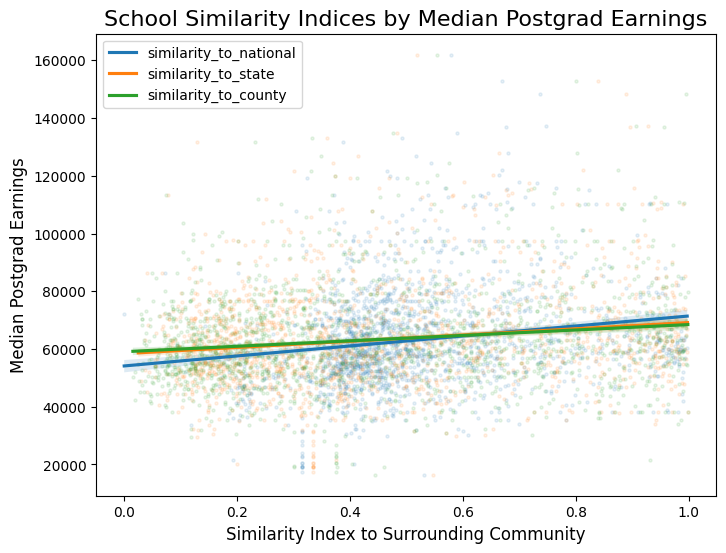

In [25]:
#changing to a regression plot to see clearer trends between racial groups

fig, ax = plt.subplots(figsize = (8,6))

for col in sim_cols: 
    sns.regplot(data = merged, x = col, y = 'md_earn_wne_4yr',  
                scatter_kws = {'alpha': 0.1, 's':5}, 
                line_kws = {'label': col}, 
                ax = ax)

ax.set_title("School Similarity Indices by Median Postgrad Earnings", fontsize = 16)
ax.set_xlabel('Similarity Index to Surrounding Community', fontsize=12)
ax.set_ylabel('Median Postgrad Earnings', fontsize=12)
plt.legend()

plt.show()

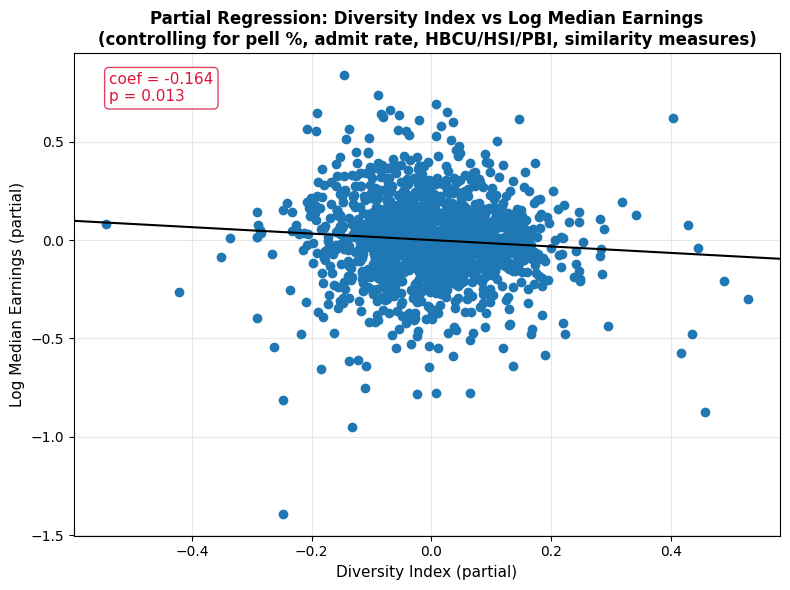

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))

other_vars = [v for v in feature_cols if v != 'diversity_index']

plot_partregress(
    endog='log_earnings',
    exog_i='diversity_index',
    exog_others=other_vars + ['const'],
    data=reg_df2_clean.assign(const=1),
    ax=ax,
    obs_labels=False
)

ax.set_title('Partial Regression: Diversity Index vs Log Median Earnings\n(controlling for pell %, admit rate, HBCU/HSI/PBI, similarity measures)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Diversity Index (partial)', fontsize=11)
ax.set_ylabel('Log Median Earnings (partial)', fontsize=11)

# Annotate with coef and p-value from model
coef = model_robust.params['diversity_index']
pval = model_robust.pvalues['diversity_index']
ax.annotate(f'coef = {coef:.3f}\np = {pval:.3f}', 
            xy=(0.05, 0.90), xycoords='axes fraction',
            fontsize=11, color='crimson',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='crimson', alpha=0.8))

ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('diversity_partial_regression.png', dpi=150, bbox_inches='tight')
plt.show()

To further investigate the nuances of institutional impact, this code generates a comparative visualization using Seaborn's regplot to contrast earnings outcomes between "Designated" and "Non-Designated" institutions. The script first creates a boolean mask to isolate Minority-Serving Institutions (HSI, HBCU, or PBI) into a "Designated" category, allowing for a direct performance comparison against the broader dataset. The resulting three-panel figure plots median earnings against geographic similarity at the national, state, and county levels.

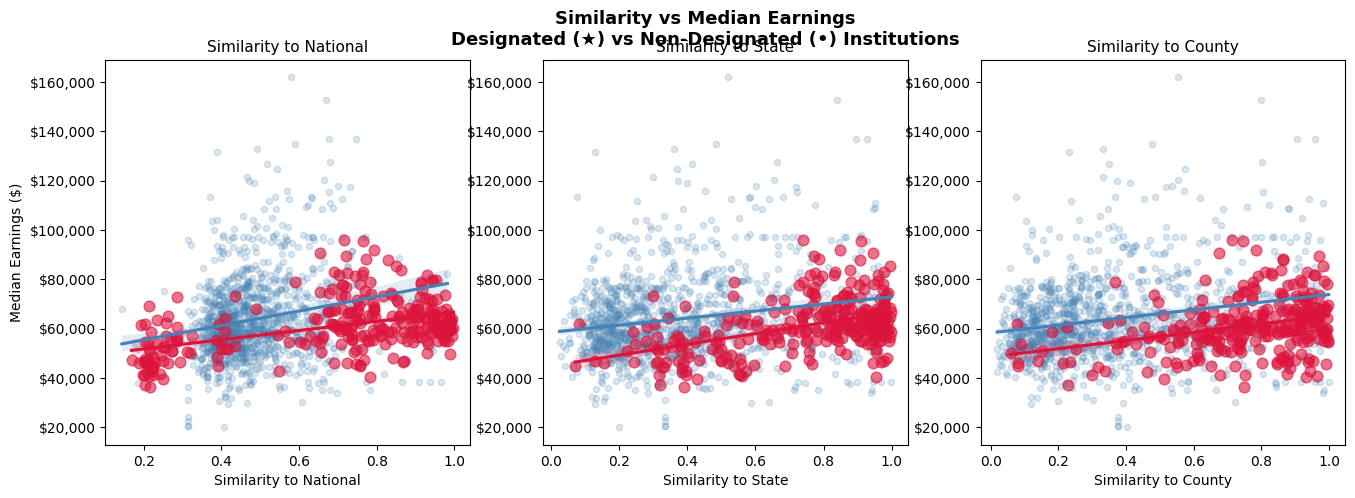

In [41]:
import seaborn as sns

# Convert designation columns to numeric first
for col in ['hsi', 'hbcu', 'pbi']:
    reg_df2_clean[col] = pd.to_numeric(reg_df2_clean[col], errors='coerce')

# Create designation mask on reg_df2_clean
designated_mask = (
    (reg_df2_clean['hsi'] >= 0.98) |
    (reg_df2_clean['hbcu'] >= 0.98) |
    (reg_df2_clean['pbi'] >= 0.98)
)

designated_df = reg_df2_clean[designated_mask]
non_designated_df = reg_df2_clean[~designated_mask]

earnings = pd.to_numeric(reg_df2_clean['md_earn_wne_4yr'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Similarity vs Median Earnings\nDesignated (Red) vs Non-Designated (Blue) Institutions',
             fontsize=13, fontweight='bold')

for ax, col, title in zip(axes, sim_cols, ['National', 'State', 'County']):
    # Non-designated
    sns.regplot(data=non_designated_df, x=col, y='earnings',
                scatter_kws={'alpha': 0.2, 's': 20, 'color': 'steelblue'},
                line_kws={'color': 'steelblue', 'label': 'Non-Designated'},
                ax=ax)
    # Designated
    sns.regplot(data=designated_df, x=col, y='earnings',
                scatter_kws={'alpha': 0.6, 's': 60, 'marker': '*', 'color': 'crimson'},
                line_kws={'color': 'crimson', 'label': 'Designated'},
                ax=ax)
    
    ax.set_title(f'Similarity to {title}', fontsize=11)
    ax.set_xlabel(f'Similarity to {title}', fontsize=10)
    ax.set_ylabel('Median Earnings ($)' if col == sim_cols[0] else '', fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

The comparative scatter plots reveal a consistent disparity between Designated (Minority-Serving Institutions) and Non-Designated institutions across all three geographic levels of demographic similarity. Across the National, State, and County metrics, designated institutions (shown in crimson) generally cluster at a lower median earnings bracket—typically between $40,000 and $70,000—compared to the wider, higher-reaching distribution of non-designated schools. Interestingly, while both groups show a positive correlation between geographic similarity and earnings, the regression slopes are remarkably parallel; this suggests that while demographic alignment with the surrounding population positively influences earnings for all schools, it does not close the fundamental "earnings gap" associated with institutional designation. Furthermore, the Similarity to National plot shows the tightest clustering at the high end of similarity for designated schools, reinforcing the earlier regression finding that national demographic alignment is a particularly significant factor for institutional outcomes.

The comprehensive analysis reveals a complex interplay between institutional demographics and economic outcomes, where initial findings suggesting a simple negative correlation between diversity and earnings were refined through more sophisticated modeling. While Admission Rate maintain significant negative associations with median earnings, the introduction of control variables—specifically Pell Grant %—uncovered that much of this effect is driven by the underlying socioeconomic challenges of the student body. Conversely, the model highlights clear paths to higher earnings through HBCU status and National Similarity, suggesting that institutions which align closely with national demographic benchmarks or provide specialized support structures for minority students can drive significant financial uplift. Ultimately, the parallel regression trends across designated and non-designated institutions indicate that while demographic alignment with the surrounding population serves as a universal positive lever for earnings, it currently operates within a tiered system where minority-serving institutions still face a persistent, baseline earnings gap relative to their non-designated peers.